# Home Assignment 2
## Path Estimation (Linear Kalman Filter)

**Data:** `2026-03-0916.48.43.csv`  
**Scenario:** the person was moving almost all the time and stood still for about 2 seconds at the end.

This notebook includes:
1. CSV loading and GPS distance in meters from the start.
2. Small EDA (time series, trajectory, speed).
3. Noise estimation for `std_acc` and `std_meas`.
4. Linear Kalman filter with `x=[position, velocity]^T` and accelerometer input `u`.
5. Final comparison plot: `GPS vs KF`.

### Imports
Load the required libraries and plotting settings.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


## 1) Data Loading

### Load CSV
Read the sensor log and show the first rows.

In [ ]:
csv_path = Path("2026-03-0916.48.43.csv")
if not csv_path.exists():
    csv_path = Path("hw2/2026-03-0916.48.43.csv")

df = pd.read_csv(csv_path, sep=";", decimal=",")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
df.columns = [c.strip() for c in df.columns]

display(df.head())
print("Shape:", df.shape)

,time,gFx,gFy,gFz,Latitude,Longitude,Speed (m/s),Altitude (m)
0,0.098396,0.2169,0.5482,0.8883,0.000000,0.00000,0.000000,191.8
1,0.198549,0.2472,0.3968,1.0730,55.747953,48.74286,0.820467,191.9
2,0.298856,0.1349,0.4055,0.7935,55.747955,48.74288,1.117462,191.9
3,0.398886,0.0078,0.4769,0.6499,55.747955,48.74288,1.117462,191.9
4,0.499002,-0.0596,0.5492,0.8590,55.747955,48.74288,1.117462,191.9


Shape: (879, 8)


### Basic Statistics
Check duration, sample interval, and valid GPS count.

In [3]:
valid_gps = (df["Latitude"] != 0) & (df["Longitude"] != 0)
dt = df["time"].diff().dropna()

print(f"Valid GPS points: {valid_gps.sum()} / {len(df)}")
print(f"Log duration: {df['time'].iloc[-1] - df['time'].iloc[0]:.2f} s")
print(f"Mean sample interval dt: {dt.mean():.4f} s (std={dt.std():.4f} s)")
print(f"GPS speed: mean={df['Speed (m/s)'].mean():.3f} m/s, max={df['Speed (m/s)'].max():.3f} m/s")


Valid GPS points: 878 / 879
Log duration: 88.27 s
Mean sample interval dt: 0.1005 s (std=0.0017 s)
GPS speed: mean=0.802 m/s, max=1.548 m/s


### Convert GPS to Local Meters
Transform latitude/longitude into local XY and compute distance signals.

In [4]:
def latlon_to_local_xy(lat_deg, lon_deg, lat0_deg, lon0_deg):
    """Convert latitude/longitude to local XY meters (planar approximation)."""
    R = 6_371_000.0
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)
    lat0 = np.deg2rad(lat0_deg)
    lon0 = np.deg2rad(lon0_deg)
    x = (lon - lon0) * np.cos((lat + lat0) / 2.0) * R
    y = (lat - lat0) * R
    return x, y

if valid_gps.sum() < 2:
    raise ValueError("Not enough valid GPS points to compute distance.")

gps = df.loc[valid_gps].copy().reset_index(drop=True)
x_m, y_m = latlon_to_local_xy(
    gps["Latitude"].to_numpy(),
    gps["Longitude"].to_numpy(),
    gps["Latitude"].iloc[0],
    gps["Longitude"].iloc[0],
)

gps["x_m"] = x_m
gps["y_m"] = y_m
gps["gps_dist_from_start_m"] = np.sqrt(x_m**2 + y_m**2)

step = np.sqrt(np.diff(x_m, prepend=x_m[0])**2 + np.diff(y_m, prepend=y_m[0])**2)
gps["gps_step_m"] = step
gps["gps_cumulative_dist_m"] = np.cumsum(step)

track_vec = np.array([x_m[-1] - x_m[0], y_m[-1] - y_m[0]])
track_unit = track_vec / np.linalg.norm(track_vec)
gps["gps_along_track_m"] = np.column_stack([x_m, y_m]) @ track_unit
gps["gps_along_track_m"] -= gps["gps_along_track_m"].iloc[0]

print(f"Distance from start (last point): {gps['gps_dist_from_start_m'].iloc[-1]:.2f} m")
print(f"GPS cumulative path length: {gps['gps_cumulative_dist_m'].iloc[-1]:.2f} m")
print(f"Along-track distance z: {gps['gps_along_track_m'].iloc[-1]:.2f} m")

gps[["time", "Latitude", "Longitude", "gps_dist_from_start_m", "gps_cumulative_dist_m", "gps_along_track_m"]].head()


Distance from start (last point): 91.75 m
GPS cumulative path length: 106.95 m
Along-track distance z: 91.75 m


,time,Latitude,Longitude,gps_dist_from_start_m,gps_cumulative_dist_m,gps_along_track_m
0,0.198549,55.747953,48.74286,0.000000,0.000000,0.000000
1,0.298856,55.747955,48.74288,1.265386,1.265386,0.855328
2,0.398886,55.747955,48.74288,1.265386,1.265386,0.855328
3,0.499002,55.747955,48.74288,1.265386,1.265386,0.855328
4,0.599715,55.747955,48.74288,1.265386,1.265386,0.855328


## Small EDA

### Time-Series EDA
Plot accelerometer channels and GPS speed, with the final stationary segment highlighted.

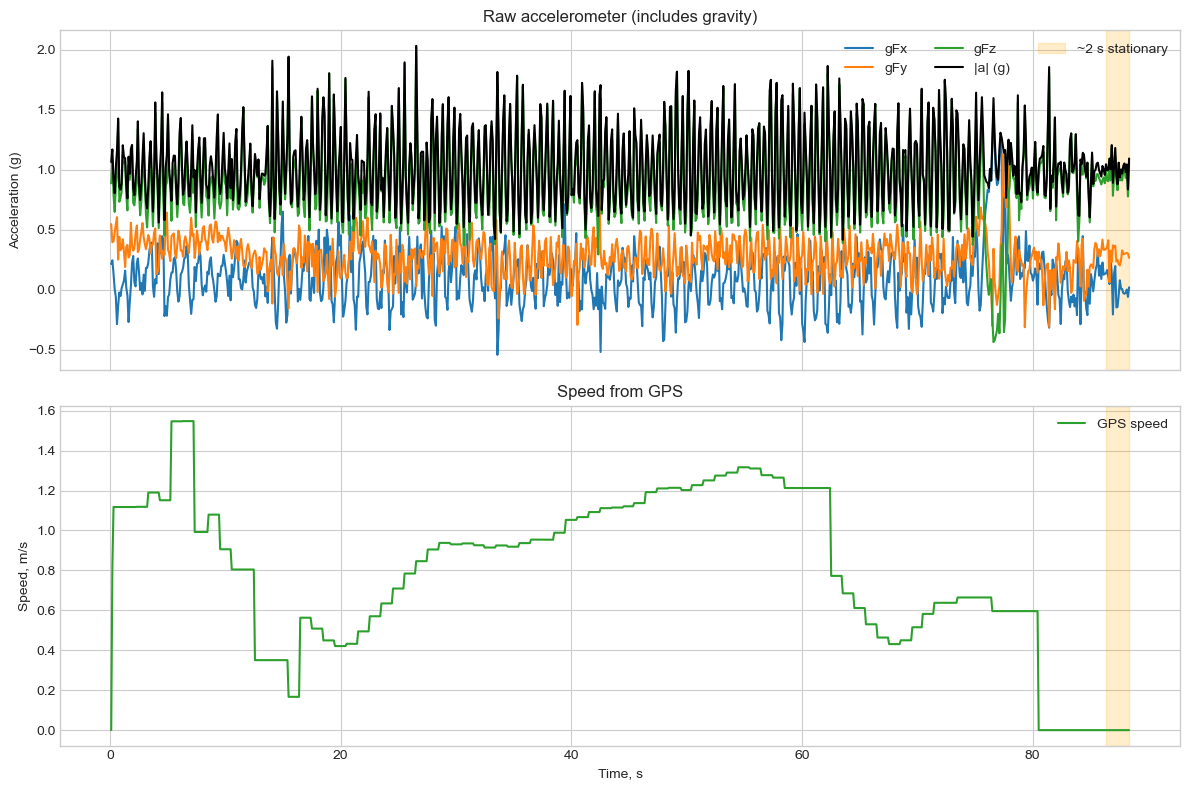

In [5]:
t = df["time"].to_numpy()
acc_g = df[["gFx", "gFy", "gFz"]].to_numpy()
acc_mag_g = np.linalg.norm(acc_g, axis=1)
stationary_mask = t >= (t.max() - 2.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, df["gFx"], label="gFx")
axes[0].plot(t, df["gFy"], label="gFy")
axes[0].plot(t, df["gFz"], label="gFz")
axes[0].plot(t, acc_mag_g, color="black", linewidth=1.5, label="|a| (g)")
axes[0].axvspan(t.max() - 2.0, t.max(), color="orange", alpha=0.2, label="~2 s stationary")
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_title("Raw accelerometer (includes gravity)")
axes[0].legend(loc="upper right", ncol=3)

axes[1].plot(t, df["Speed (m/s)"], color="tab:green", label="GPS speed")
axes[1].axvspan(t.max() - 2.0, t.max(), color="orange", alpha=0.2)
axes[1].set_xlabel("Time, s")
axes[1].set_ylabel("Speed, m/s")
axes[1].set_title("Speed from GPS")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


### Trajectory EDA
Visualize GPS trajectory and compare distance definitions.

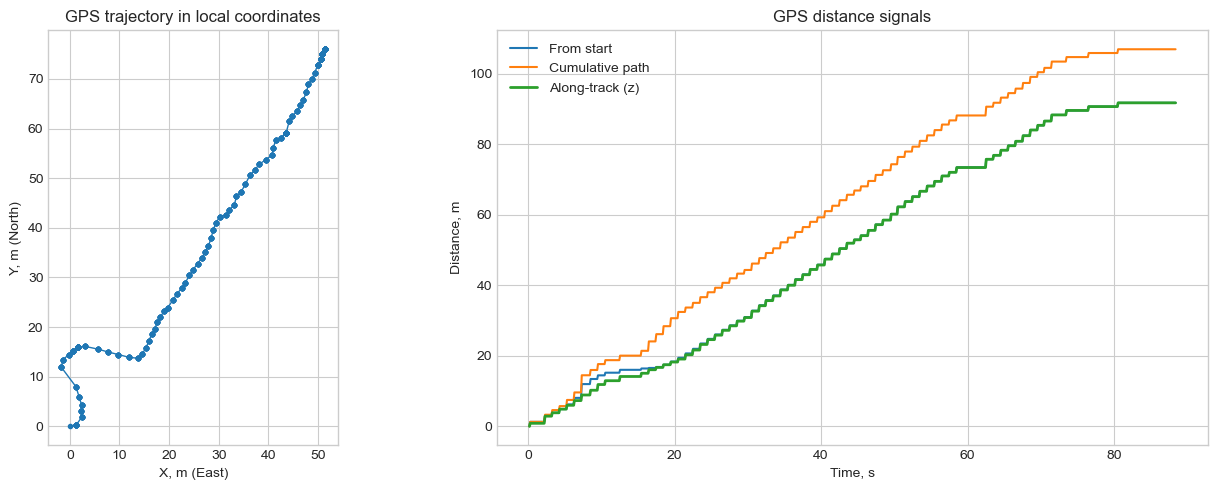

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gps["x_m"], gps["y_m"], ".-", linewidth=1)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("X, m (East)")
axes[0].set_ylabel("Y, m (North)")
axes[0].set_title("GPS trajectory in local coordinates")

axes[1].plot(gps["time"], gps["gps_dist_from_start_m"], label="From start")
axes[1].plot(gps["time"], gps["gps_cumulative_dist_m"], label="Cumulative path")
axes[1].plot(gps["time"], gps["gps_along_track_m"], label="Along-track (z)", linewidth=2)
axes[1].set_xlabel("Time, s")
axes[1].set_ylabel("Distance, m")
axes[1].set_title("GPS distance signals")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2) Noise Parameters

### Estimate Noise
Estimate `std_acc` and `std_meas` while accounting for gravity in accelerometer data.

In [7]:
G = 9.81
acc_raw = df[["gFx", "gFy", "gFz"]].to_numpy() * G
speed_all = df["Speed (m/s)"].to_numpy()

alpha = 0.60
gravity_lp = np.zeros_like(acc_raw)
gravity_lp[0] = acc_raw[0]
for k in range(1, len(acc_raw)):
    gravity_lp[k] = alpha * gravity_lp[k - 1] + (1.0 - alpha) * acc_raw[k]

acc_lin = acc_raw - gravity_lp

stationary_mask = t >= (t.max() - 2.0)
g_dir = acc_raw[stationary_mask].mean(axis=0)
g_dir = g_dir / np.linalg.norm(g_dir)

acc_horizontal = acc_lin - np.outer(acc_lin @ g_dir, g_dir)
motion_mask = (speed_all > 0.3) & (~stationary_mask)
X = acc_horizontal[motion_mask]
if X.shape[0] >= 3:
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    move_axis = vt[0] / np.linalg.norm(vt[0])
else:
    move_axis = np.array([1.0, 0.0, 0.0])

u_all = acc_horizontal @ move_axis

acc_bias = np.mean(u_all[stationary_mask])
u_all = u_all - acc_bias

std_acc = np.std(u_all[stationary_mask], ddof=1)
if not np.isfinite(std_acc) or std_acc < 0.1:
    std_acc = 0.1

gps_stationary_mask = gps["time"].to_numpy() >= (t.max() - 2.0)
std_meas_from_data = np.std(gps.loc[gps_stationary_mask, "gps_along_track_m"], ddof=1)
std_meas = std_meas_from_data if np.isfinite(std_meas_from_data) and std_meas_from_data > 0.5 else 3.0

print(f"move_axis (phone frame): {move_axis}")
print(f"acc_bias = {acc_bias:.3f} m/s^2")
print(f"std_acc = {std_acc:.3f} m/s^2")
print(f"std_meas_from_data = {std_meas_from_data:.3f} m")
print(f"std_meas used in KF = {std_meas:.3f} m")


move_axis (phone frame): [-0.99888693 -0.03118588  0.03538857]
acc_bias = 0.115 m/s^2
std_acc = 0.740 m/s^2
std_meas_from_data = 0.000 m
std_meas used in KF = 3.000 m


### Control Input `u(t)`
Inspect the projected acceleration signal used by the filter.

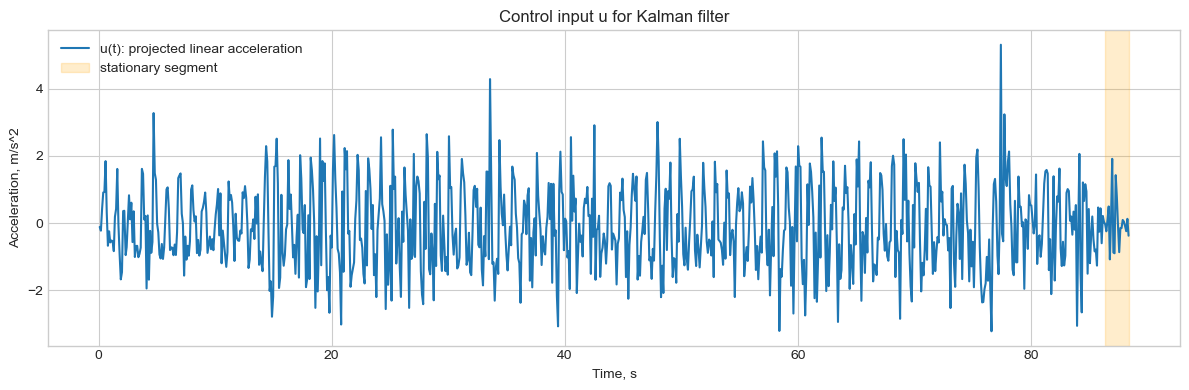

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(t, u_all, label="u(t): projected linear acceleration")
plt.axvspan(t.max() - 2.0, t.max(), color="orange", alpha=0.2, label="stationary segment")
plt.xlabel("Time, s")
plt.ylabel("Acceleration, m/s^2")
plt.title("Control input u for Kalman filter")
plt.legend()
plt.tight_layout()
plt.show()


## 3) Linear Kalman Filter

### KF Function
Define a 1D linear Kalman filter for state `x=[position, velocity]^T`.

In [ ]:
def run_linear_kf(time_s, z_m, u_m_s2, std_acc, std_meas, v0=0.0):
    n = len(time_s)
    states = np.zeros((n, 2), dtype=float)

    x = np.array([z_m[0], v0], dtype=float)
    P = np.diag([25.0, 4.0])

    H = np.array([[1.0, 0.0]])
    R = np.array([[std_meas**2]])
    I = np.eye(2)

    states[0] = x

    for k in range(1, n):
        dt = max(float(time_s[k] - time_s[k - 1]), 1e-3)

        A = np.array([[1.0, dt],
                      [0.0, 1.0]])
        B = np.array([0.5 * dt**2, dt])

        q = std_acc**2
        Q = q * np.array([[dt**4 / 4.0, dt**3 / 2.0],
                          [dt**3 / 2.0, dt**2]])

        x = A @ x + B * u_m_s2[k]
        P = A @ P @ A.T + Q

        y = z_m[k] - (H @ x)[0]
        S = H @ P @ H.T + R
        K = (P @ H.T) / S[0, 0]

        x = x + K[:, 0] * y
        P = (I - K @ H) @ P

        states[k] = x

    return states

### Run the Filter
Prepare `z` and `u`, run KF, and compute metrics.

In [ ]:
idx_valid = np.flatnonzero(valid_gps.to_numpy())
time_kf = gps["time"].to_numpy()
z_kf = gps["gps_along_track_m"].to_numpy()
u_kf = u_all[idx_valid]

v0 = max(float(gps["Speed (m/s)"].iloc[0]), 0.0)
states = run_linear_kf(time_kf, z_kf, u_kf, std_acc, std_meas, v0=v0)

gps["kf_pos_m"] = states[:, 0]
gps["kf_vel_m_s"] = states[:, 1]

rmse = np.sqrt(np.mean((gps["kf_pos_m"] - gps["gps_along_track_m"])**2))

print(f"RMSE(KF vs GPS z): {rmse:.3f} m")
print(f"Final distance from GPS (z): {gps['gps_along_track_m'].iloc[-1]:.2f} m")
print(f"Final distance from KF:      {gps['kf_pos_m'].iloc[-1]:.2f} m")

RMSE(KF vs GPS z): 0.676 m
Final distance from GPS (z): 91.75 m
Final distance from KF:      91.39 m


## 4) Result

### Final Plots
Compare GPS distance measurement with Kalman estimate and inspect estimated speed.

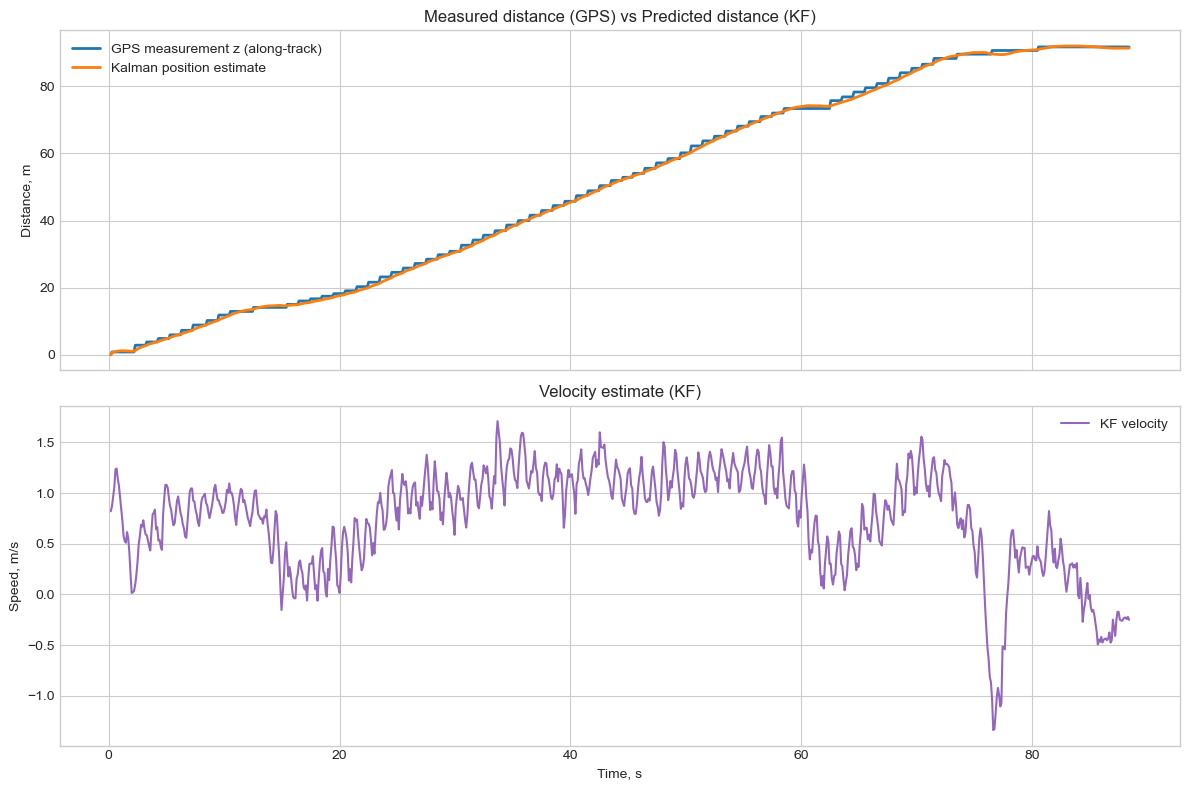

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(gps["time"], gps["gps_along_track_m"], label="GPS measurement z (along-track)", linewidth=2)
axes[0].plot(gps["time"], gps["kf_pos_m"], label="Kalman position estimate", linewidth=2)
axes[0].set_ylabel("Distance, m")
axes[0].set_title("Measured distance (GPS) vs Predicted distance (KF)")
axes[0].legend()

axes[1].plot(gps["time"], gps["kf_vel_m_s"], color="tab:purple", label="KF velocity")
axes[1].set_xlabel("Time, s")
axes[1].set_ylabel("Speed, m/s")
axes[1].set_title("Velocity estimate (KF)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Short Conclusion
- Data quality is high: **878/879** valid GPS points over **88.27 s**, with mean sampling interval **0.1005 +/- 0.0017 s**.
- Motion scale is consistent: GPS speed is **0.802 m/s** on average (max **1.548 m/s**), final along-track distance is **91.75 m** (cumulative path length **106.95 m**).
- Noise calibration: from the final ~2 s stationary segment we get `acc_bias = 0.115 m/s^2` and `std_acc = 0.740 m/s^2`; stationary GPS spread is quantized (`std_meas_from_data = 0.000 m`), so fallback `std_meas = 3.000 m` is used.
- KF performance: **RMSE = 0.676 m** versus GPS along-track `z`; final KF distance is **91.39 m** vs GPS **91.75 m** (absolute difference **0.36 m**), with a visibly smoother and more stable trajectory estimate.